## 0. Import librerie e inizializzazione

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
import random

from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
np.random.seed(42)
random.seed(42)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.svm._base')

### 0.1 Import dataset

In [24]:
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
df = pd.read_csv(path + "/breast-cancer.csv")
print(f"Dataset caricato. Dimensioni: {df.shape}")
df.head()

Dataset caricato. Dimensioni: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 0.2 Analisi preliminare dataset

In [25]:
print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.\n")
df.info()
display(df.describe())

missing_values = df.isnull().sum()
print("Valori mancanti per colonna:\n", missing_values[missing_values > 0])

Il dataset contiene 569 righe e 32 colonne.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-nu

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Valori mancanti per colonna:
 Series([], dtype: int64)


### 0.3 Analisi target

diagnosis
B    357
M    212
Name: count, dtype: int64
Percentuali:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_24464\3572314673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


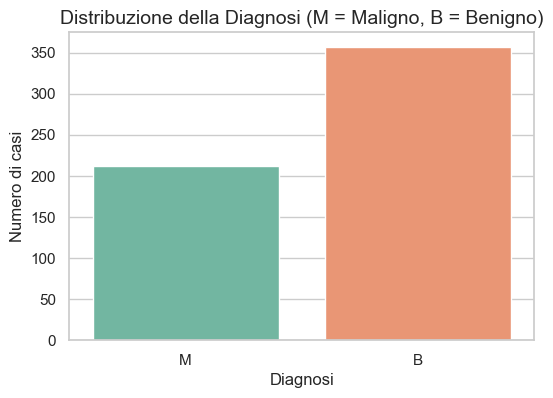

In [26]:
print(df['diagnosis'].value_counts())
print(f"Percentuali:\n{df['diagnosis'].value_counts(normalize=True) * 100}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribuzione della Diagnosi (M = Maligno, B = Benigno)', fontsize=14)
plt.xlabel('Diagnosi')
plt.ylabel('Numero di casi')
plt.show()

df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

### 0.4 Analisi features

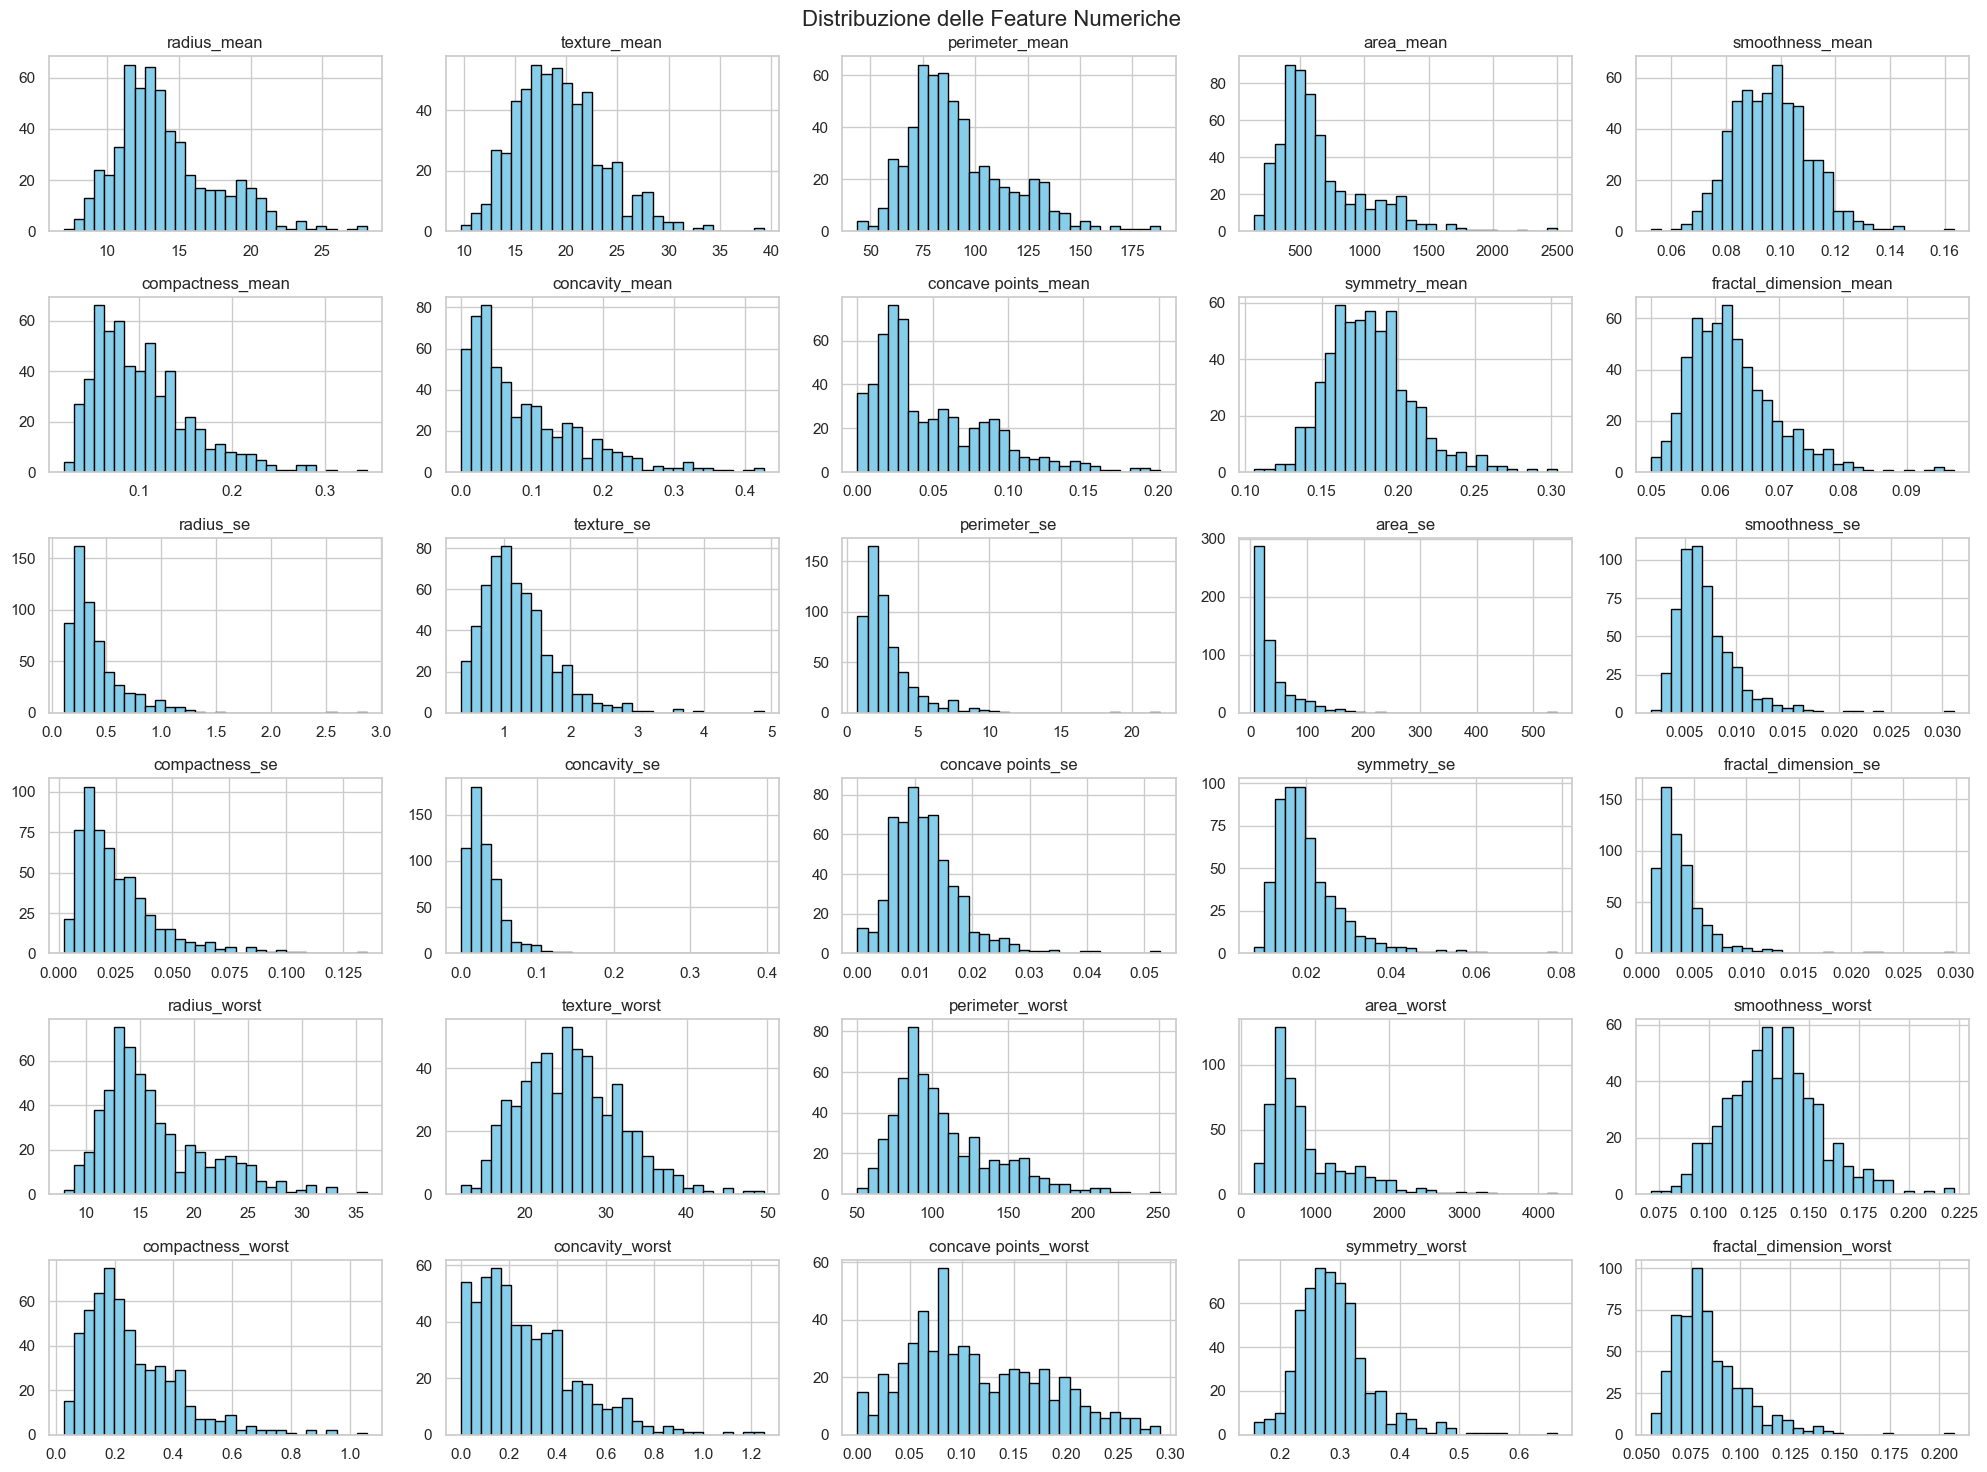

In [27]:
features = df.drop(['id', 'diagnosis'], axis=1)
diagnosis = df['diagnosis']

features.hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Distribuzione delle Feature Numeriche', fontsize=16)
plt.tight_layout()
plt.show()

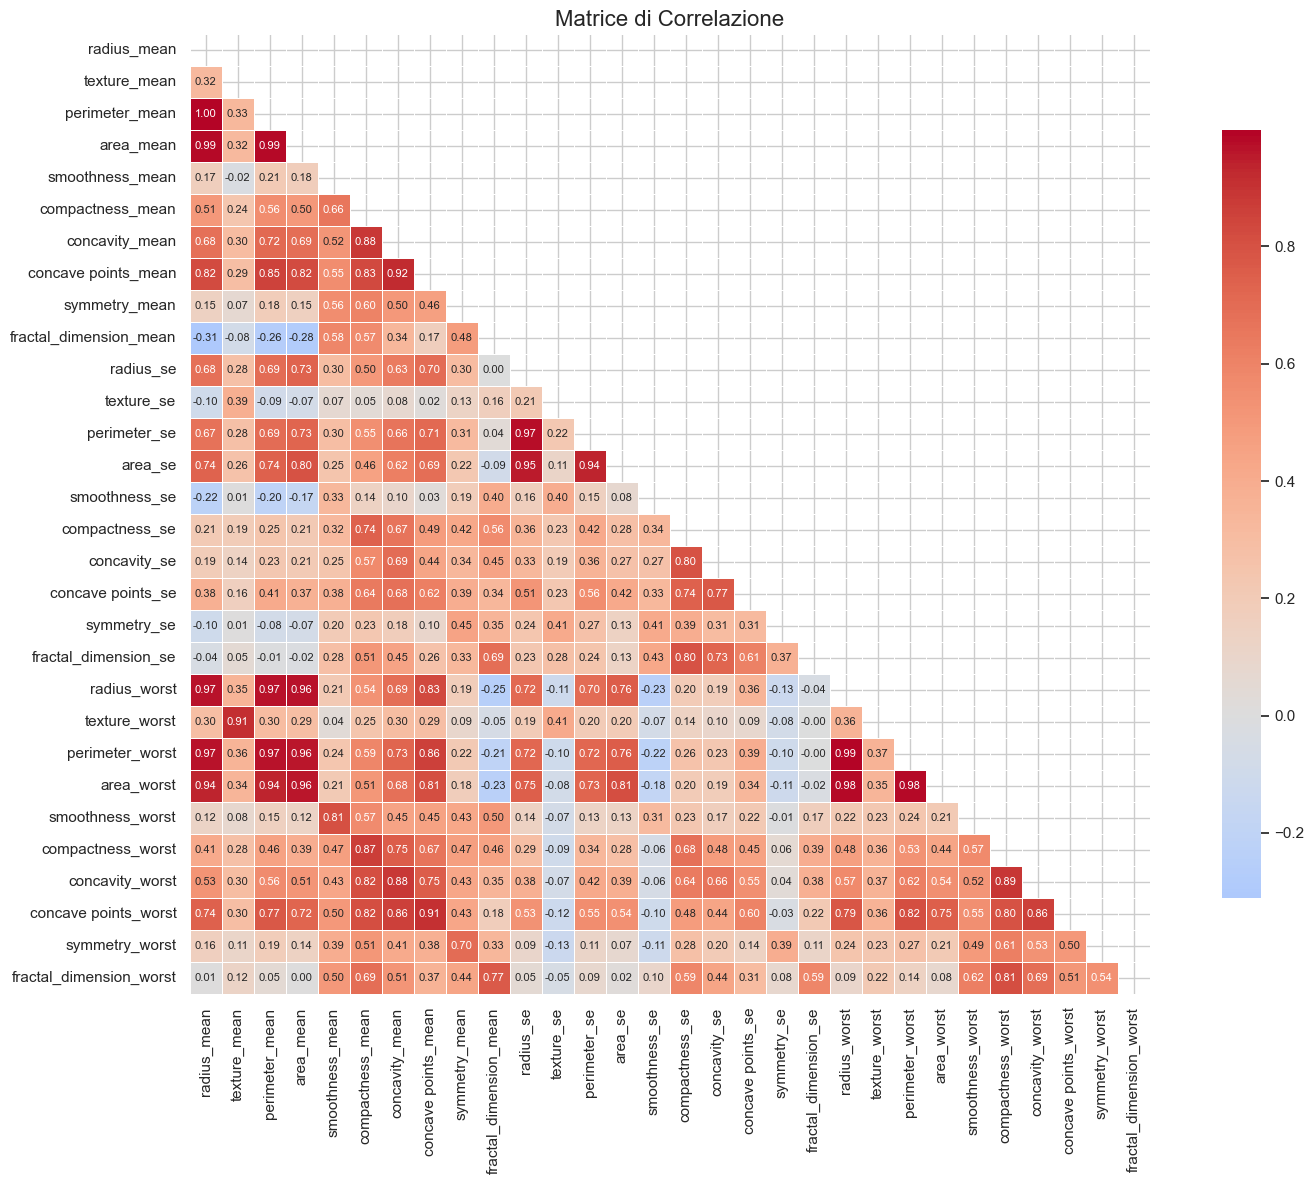

In [28]:
# Matrice di correlazione (solo triangolo inferiore)
correlation_matrix = features.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={'size': 8})
plt.title('Matrice di Correlazione', fontsize=16)
plt.tight_layout()
plt.show()

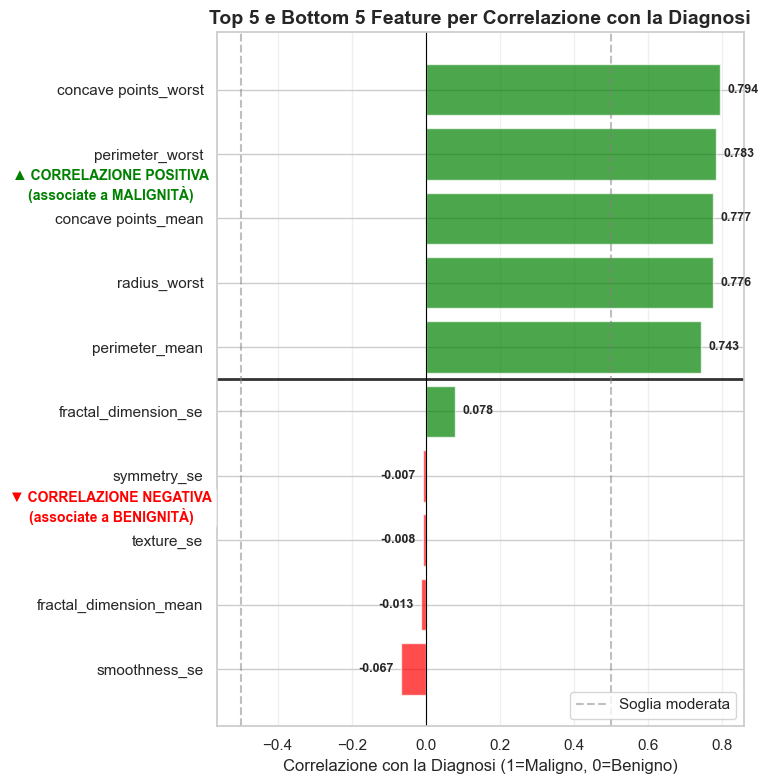

In [29]:
# Top 5 e Bottom 5 feature per correlazione con il target
corr_with_target = (
    pd.concat([features, diagnosis], axis=1)
    .corr()['diagnosis']
    .drop('diagnosis')
    .sort_values()
)
selected_corr = pd.concat([corr_with_target.head(5), corr_with_target.tail(5)])
colors = ['red' if x < 0 else 'green' for x in selected_corr.values]

plt.figure(figsize=(8, 8))
bars = plt.barh(selected_corr.index, selected_corr.values, color=colors, alpha=0.7)
plt.axhline(y=4.5, color='black', linewidth=2, alpha=0.8)
plt.text(-0.85, 2.5, '▼ CORRELAZIONE NEGATIVA\n(associate a BENIGNITÀ)',
         ha='center', va='center', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(-0.85, 7.5, '▲ CORRELAZIONE POSITIVA\n(associate a MALIGNITÀ)',
         ha='center', va='center', fontsize=10, color='green', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
for bar, val in zip(bars, selected_corr.values):
    kwargs = dict(y=bar.get_y() + bar.get_height()/2, va='center', fontsize=9, fontweight='bold')
    if val > 0:
        plt.text(bar.get_width() + 0.02, ha='left', s=f'{val:.3f}', **kwargs)
    else:
        plt.text(bar.get_width() - 0.02, ha='right', s=f'{val:.3f}', **kwargs)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Soglia moderata')
plt.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Correlazione con la Diagnosi (1=Maligno, 0=Benigno)', fontsize=12)
plt.title('Top 5 e Bottom 5 Feature per Correlazione con la Diagnosi', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [30]:
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(features, diagnosis)

importance_df = pd.DataFrame({
    'feature': features.columns,
    'importance': rf_temp.feature_importances_
}).sort_values(by='importance', ascending=False)

C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_24464\3873262260.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


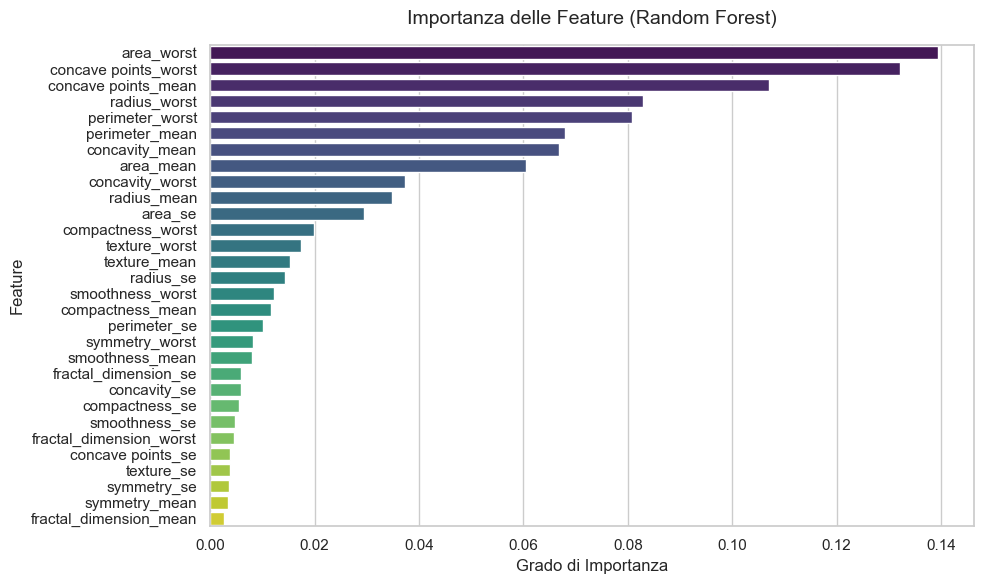

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Configura le dimensioni globali del grafico senza usare plt.figure()
plt.rcParams["figure.figsize"] = (10, 6)

# Crea il grafico a barre orizzontali (i dati sono già ordinati nel tuo dataframe)
ax = sns.barplot(
    x="importance", y="feature", data=importance_df, palette="viridis"
)

# Aggiunge titoli e label agli assi
plt.title("Importanza delle Feature (Random Forest)", fontsize=14, pad=15)
plt.xlabel("Grado di Importanza", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Ottimizza i margini per evitare il taglio dei testi
plt.tight_layout()

# Salva il grafico come immagine ad alta risoluzione nella cartella corrente
plt.savefig("risultati/importanza_feature.png", bbox_inches="tight", dpi=300)
plt.show()


## 1. Preparazione dataset

In [32]:
X = features
y = diagnosis

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 455, Test size: 114


In [35]:
# ==================== CONFIGURAZIONE STILI E FILTRI ====================
# Il flag 'is_generic':
# - True: il metodo è generico (indipendente dal filtro), quindi compare SOLO in 'all'
# - False: il metodo dipende dalle feature, quindi compare in TUTTI i grafici
# ==================== CONFIGURAZIONE STILI E FILTRI ESTESA ====================
# - is_generic: True  -> Il metodo è indipendente dal filtro (compare SOLO in 'all')
# - is_generic: False -> Il metodo risente della selezione (compare in TUTTI i grafici)
CORRUPTION_STYLES = {
    # Metodi Generici / Globali (SOLO in 'all')
    "label_flipping": {
        "color": "#E66101",
        "marker": "o",
        "is_generic": True,
    },  # Arancione scuro
    "top_k_drop": {
        "color": "#D62728",
        "marker": "X",
        "is_generic": True,
    },  # Rosso
    "random_feature_drop": {
        "color": "#7F7F7F",
        "marker": "v",
        "is_generic": True,
    },  # Grigio
    # Metodi Dipendenti dal Selection Mode (In TUTTI i grafici)
    "gaussian_noise": {
        "color": "#B2ABD2",
        "marker": "s",
        "is_generic": False,
    },  # Viola chiaro
    "outliers": {
        "color": "#5E3C99",
        "marker": "^",
        "is_generic": False,
    },  # Viola scuro
    "missing_features": {
        "color": "#FDB863",
        "marker": "D",
        "is_generic": False,
    },  # Arancione chiaro
    "data_drift": {
        "color": "#1F77B4",
        "marker": "P",
        "is_generic": False,
    },  # Blu scuro
    "feature_swapping": {
        "color": "#2CA02C",
        "marker": "*",
        "is_generic": False,
    },  # Verde
}


### 1.1 Funzioni di sporcamento

In [33]:
import numpy as np
import pandas as pd
from pucktrick.labels import labels
from pucktrick.noisy import noise
from pucktrick.missing import missing
from pucktrick.outliers import outlier
from sklearn.ensemble import RandomForestClassifier

# --- 1. Selezione Dinamica delle Feature ---

def _get_selected_features(X, y, selection_mode, k=3):
    """
    Calcola dinamicamente l'importanza delle feature basandosi sui dati correnti
    e isola il sottoinsieme richiesto ('best 3', 'worst 3', 'all').
    """
    # Uniformiamo le stringhe per evitare problemi di formattazione (es. 'best 3' -> 'best_3')
    mode = selection_mode.replace(" ", "_")
    
    if mode == 'all' or k is None or k >= len(X.columns):
        return list(X.columns)
    
    # Calcola l'importanza delle feature in tempo reale
    rf_temp = RandomForestClassifier(random_state=42)
    rf_temp.fit(X, y)
    
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    if mode == 'best_3':
        return importance_df['feature'].head(k).tolist()
    elif mode == 'worst_3':
        return importance_df['feature'].tail(k).tolist()
        
    return list(X.columns)


# --- 2. Funzioni di Corruzione Aggiornate con Pucktrick ---

def add_label_flipping( y, noise_ratio, label_column_name="target"):
    """Inverte i label utilizzando la libreria pucktrick."""
    df = y.copy()
    strategy = {
        "affected_features": [label_column_name],
        "selection_criteria": "all",
        "percentage": noise_ratio,
        "mode": "new"
    }
    _, df_corrupted = labels(df, strategy)
    return df_corrupted[label_column_name]


def add_gaussian_noise(X, y, noise_ratio, selection_mode='all'):
    """Aggiunge rumore alle feature selezionate tramite pucktrick."""
    candidate_cols = _get_selected_features(X, y, selection_mode, k=3)
    
    # Calcola quante feature corrompere all'interno della selezione
    n_noisy_features = max(1, int(len(candidate_cols) * noise_ratio)) if noise_ratio < 1.0 else len(candidate_cols)
    affected_cols = list(np.random.choice(candidate_cols, n_noisy_features, replace=False))
    
    if not affected_cols:
        return X.copy()
        
    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": 1.0,  
        "mode": "new",
        "distribution": "random"
    }
    _, X_corrupted = noise(X, strategy)
    return X_corrupted


def add_outliers(X, y, outlier_ratio, selection_mode='all'):
    """Inietta outlier nelle feature selezionate tramite pucktrick."""
    affected_cols = _get_selected_features(X, y, selection_mode, k=3)
    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": outlier_ratio,
        "mode": "new"
    }
    _, X_corrupted = outlier(X, strategy)
    return X_corrupted


def add_missing_features(X, y, missing_ratio, selection_mode='all'):
    """Introduce valori mancanti nelle feature selezionate e imputa a 0."""
    affected_cols = _get_selected_features(X, y, selection_mode, k=3)
    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": missing_ratio,
        "mode": "new"
    }
    _, X_corrupted = missing(X, strategy)
    # Applica l'imputazione a 0 richiesta dalla logica originale
    X_corrupted[affected_cols] = X_corrupted[affected_cols].fillna(0)
    return X_corrupted

# --- 1. Data Drift con Pucktrick (Modulo Noisy - Shift) ---
def add_data_drift(X, y, drift_ratio, selection_mode='all'):
    """
    Usa il modulo noise di Pucktrick in modalità 'shift' basata su STD 
    per generare una deriva sistematica dei dati numerici.
    """
    X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    affected_cols = _get_selected_features(X_df, y, selection_mode, k=3)
    
    if not affected_cols:
        return X_df

    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": drift_ratio,  # Percentuale di righe colpite dal drift
        "mode": "new",
        "distribution": "shift",    # Attiva l'algoritmo di sfasamento lineare
        "shift_value": 1.0,         # Entità dello shift (1.0 * unità)
        "shift_unit": "std",        # Sposta i dati in base alla deviazione standard
        "shift_sign": "random"      # Segno casuale (+ o -) per simulare instabilità
    }
    
    _, X_corrupted = noise(X_df, strategy)
    return X_corrupted


# --- 2. Feature Swapping con Pucktrick (Modulo Outliers) ---
def add_feature_swapping(X, y, swap_ratio, selection_mode='all'):
    """
    Pucktrick non ha un modulo nativo chiamato 'swap', ma il suo modulo 'outlier' 
    permette di scambiare valori fuori scala estraendoli dal dominio massimo.
    Per simulare lo swapping puro, usiamo il modulo outlier configurato per rimpiazzare 
    i dati con valori estremi opposti presi dalle feature stesse del dataset.
    """
    X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    affected_cols = _get_selected_features(X_df, y, selection_mode, k=3)
    
    if len(affected_cols) < 2:
        return X_df

    strategy = {
        "affected_features": affected_cols,
        "selection_criteria": "all",
        "percentage": swap_ratio,
        "mode": "new"
    }
    
    # Sfrutta l'iniettore outlier di Pucktrick per distorcere le relazioni inter-feature
    _, X_corrupted = outlier(X_df, strategy)
    return X_corrupted


# --- 3. Rimozione Casuale di Feature con Pucktrick (Modulo Missing + Imputazione) ---
def add_random_feature_drop(X, y, drop_ratio, selection_mode='all'):
    """
    Usa il modulo missing di Pucktrick per rimuovere l'informazione (NaN) 
    dalle feature selezionate casualmente, per poi azzerarle.
    """
    X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    candidate_cols = _get_selected_features(X_df, y, selection_mode, k=3)
    
    n_cols_to_drop = max(1, int(len(candidate_cols) * drop_ratio)) if drop_ratio < 1.0 else len(candidate_cols)
    cols_to_drop = list(np.random.choice(candidate_cols, n_cols_to_drop, replace=False))
    
    if not cols_to_drop:
        return X_df

    strategy = {
        "affected_features": cols_to_drop,
        "selection_criteria": "all",
        "percentage": 1.0,  # Rimuove il 100% dei valori di quella colonna
        "mode": "new"
    }
    
    _, X_corrupted = missing(X_df, strategy)
    
    # Standardizzazione post-Pucktrick: riempie i vuoti generati con 0.0
    X_corrupted[cols_to_drop] = X_corrupted[cols_to_drop].fillna(0.0)
    return X_corrupted


# --- 4. Togliere le Top K Feature più importanti con Pucktrick ---
def add_top_k_drop(X, y, drop_ratio, selection_mode='all'):
    """
    Identifica le feature dominanti e usa il modulo missing di Pucktrick 
    per cancellarle totalmente dal dataset prima dell'addestramento.
    """
    X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    
    # Calcolo dell'importanza per identificare i bersagli della corruzione
    rf_temp = RandomForestClassifier(random_state=42)
    rf_temp.fit(X_df, y)
    
    importance_df = pd.DataFrame({
        'feature': X_df.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    k = max(1, int(len(X_df.columns) * drop_ratio))
    top_k_features = importance_df['feature'].head(k).tolist()
    
    strategy = {
        "affected_features": top_k_features,
        "selection_criteria": "all",
        "percentage": 1.0,  # Oscura completamente le top feature
        "mode": "new"
    }
    
    _, X_corrupted = missing(X_df, strategy)
    X_corrupted[top_k_features] = X_corrupted[top_k_features].fillna(0.0)
    return X_corrupted

# --- 3. Nuovo Dispatcher Centralizzato ---

# Il dispatcher ora accetta (X, y, ratio, selection_mode) e gestisce la separazione corretta delle variabili
CORRUPTION_FNS = {
    'label_flipping':   lambda X, y, r, m: (X.copy(), add_label_flipping(y, r)),
    'gaussian_noise':   lambda X, y, r, m: (add_gaussian_noise(X, y, r, m), y.copy()),
    'outliers':         lambda X, y, r, m: (add_outliers(X, y, r, m), y.copy()),
    'missing_features': lambda X, y, r, m: (add_missing_features(X, y, r, m), y.copy()),
    'data_drift':          lambda X, y, r, m: (add_data_drift(X, y, r, m), y.copy() if hasattr(y, 'copy') else np.copy(y)),
    'feature_swapping':    lambda X, y, r, m: (add_feature_swapping(X, y, r, m), y.copy() if hasattr(y, 'copy') else np.copy(y)),
    'random_feature_drop': lambda X, y, r, m: (add_random_feature_drop(X, y, r, m), y.copy() if hasattr(y, 'copy') else np.copy(y)),
    'top_k_drop':          lambda X, y, r, m: (add_top_k_drop(X, y, r, m), y.copy() if hasattr(y, 'copy') else np.copy(y)),
}

### 1.2 Creazione e standardizzazione dataset corrotti

In [39]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

CORRUPTION_LEVELS = list(np.arange(0.05, 1.0, 0.05))
CORRUPTION_TYPES = list(CORRUPTION_FNS.keys())
SELECTION_MODES = ["all", "best 3", "worst 3"]


def standardize(X_tr, X_te):
    """Fit scaler su train, trasforma entrambi; restituisce DataFrame."""
    scaler = StandardScaler()

    def to_df(arr, ref):
        return pd.DataFrame(arr, columns=ref.columns, index=ref.index)

    return to_df(scaler.fit_transform(X_tr), X_tr), to_df(
        scaler.transform(X_te), X_te
    )


# 1. Genera la baseline pulita una sola volta
X_tr_base, X_te_base = standardize(X_train, X_test)

# Inizializzazione della struttura ad albero
standardized_datasets = {
    mode: {corr: {} for corr in CORRUPTION_TYPES} for mode in SELECTION_MODES
}

# ==================== GENERAZIONE OTTIMIZZATA ====================

for mode in SELECTION_MODES:
    for corr_type in CORRUPTION_TYPES:

        # Recuperiamo se l'attacco corrente è generico o specifico
        is_generic = CORRUPTION_STYLES.get(corr_type, {}).get(
            "is_generic", False
        )

        # SE il metodo è generico E non siamo nel primo ciclo ('all'),
        # copiamo il riferimento dei dati già calcolati in 'all'
        if is_generic and mode != "all":
            standardized_datasets[mode][corr_type] = standardized_datasets[
                "all"
            ][corr_type]
            continue  # Salta al prossimo attacco, ottimizzazione completata!

        # --- Generazione Standard ---

        # Baseline (level 0) pulita e identica
        standardized_datasets[mode][corr_type][0] = {
            "X_train": X_tr_base,
            "X_test": X_te_base,
            "y_train": y_train,
            "y_test": y_test,
        }

        for level in CORRUPTION_LEVELS:
            # CORRETTO: Esecuzione del dispatcher senza sovrascrivere il dizionario
            X_corr, y_corr = CORRUPTION_FNS[corr_type](
                X_train, y_train, level, mode
            )

            # Standardizzazione locale
            X_tr_s, X_te_s = standardize(X_corr, X_test)

            # Salvataggio nel dizionario tridimensionale
            standardized_datasets[mode][corr_type][level] = {
                "X_train": X_tr_s,
                "X_test": X_te_s,
                "y_train": y_corr,
                "y_test": y_test,
            }

print(
    "-> Generazione completata con successo (con ottimizzazione dei filtri generici)."
)

KeyError: 'target'

## 2. Addestramento e valutazione

In [ ]:
import random
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluate(model, X_train, y_train, X_test, y_test):
    """Addestra il modello e restituisce un dict con le metriche."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
        'recall':    recall_score(y_test, y_pred,    average='binary', zero_division=0),
        'f1_score':  f1_score(y_test, y_pred,        average='binary', zero_division=0),
    }


# --- Configurazione e parametri globali ---
Iterazioni = 20
MODES = ['all', 'best 3', 'worst 3']
CORRUPTION_TYPES = list(CORRUPTION_FNS.keys())

# Lista globale per raccogliere i dati di ogni singola iterazione
all_runs_records = []

# ==================== AVVIO SIMULAZIONE ====================

for mode in MODES:
    print(f"\n================ Avvio Simulazione: Modalità {mode.upper()} ================")
    
    for run in range(Iterazioni):
        print(f"--- Inizio Run {run + 1}/{Iterazioni} per Modalità: {mode} ---")
        
        # 1. Gestione del Seed dinamico per riproducibilità e variabilità
        current_seed = 42 + run
        np.random.seed(current_seed)
        random.seed(current_seed)
        
        # 2. Rigenerazione locale del dataset corrotto per questa combinazione
        X_tr_base, X_te_base = standardize(X_train, X_test)
        standardized_datasets = {}

        for corr_type in CORRUPTION_TYPES:
            standardized_datasets[corr_type] = {}
            # Baseline (livello 0)
            standardized_datasets[corr_type][0] = {
                'X_train': X_tr_base, 'X_test': X_te_base,
                'y_train': y_train, 'y_test': y_test
            }

            for level in CORRUPTION_LEVELS:
                # Modificato: Passiamo 'mode' come 4° parametro al nuovo dispatcher Pucktrick
                X_corr, y_corr = CORRUPTION_FNS[corr_type](X_train, y_train, level, mode)
                X_tr_s, X_te_s = standardize(X_corr, X_test)
                standardized_datasets[corr_type][level] = {
                    'X_train': X_tr_s, 'X_test': X_te_s,
                    'y_train': y_corr, 'y_test': y_test
                }
                
        # 3. Re-inizializzazione dei modelli con il seed corrente del run
        MODELS = {
            'SVM': SVC(kernel='linear', C=1.0, random_state=current_seed),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=current_seed),
            'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                 alpha=0.0001, early_stopping=True,
                                 validation_fraction=0.1, max_iter=200,
                                 random_state=current_seed),
        }
        
        # 4. Loop di addestramento e valutazione
        for model_name, model in MODELS.items():
            for corr_type in CORRUPTION_TYPES:
                for level, data in standardized_datasets[corr_type].items():
                    metrics = evaluate(
                        model,
                        data['X_train'], data['y_train'],
                        data['X_test'], data['y_test']
                    )
                    # Aggiungiamo anche il record della 'selection_mode'
                    all_runs_records.append({
                        'run': run,
                        'selection_mode': mode,
                        'model': model_name,
                        'corruption_type': corr_type,
                        'corruption_level': level,
                        **metrics
                    })

# 5. Trasformazione in DataFrame globale di tutti i run e tutte le modalità
df_all_runs = pd.DataFrame(all_runs_records)

# 6. Aggregazione dei risultati (Media calcolata includendo 'selection_mode')
results_df = df_all_runs.groupby(['selection_mode', 'model', 'corruption_type', 'corruption_level']).mean().reset_index()

# Rimuoviamo la colonna 'run' inutile ai fini dell'output finale
if 'run' in results_df.columns:
    results_df = results_df.drop(columns=['run'])

print("\n--- Addestramento completato su tutti i run e tutte le modalità. Risultati medi pronti. ---")


================ Avvio Simulazione: Modalità ALL ================
--- Inizio Run 1/20 per Modalità: all ---
--- Inizio Run 2/20 per Modalità: all ---
--- Inizio Run 3/20 per Modalità: all ---
--- Inizio Run 4/20 per Modalità: all ---
--- Inizio Run 5/20 per Modalità: all ---
--- Inizio Run 6/20 per Modalità: all ---
--- Inizio Run 7/20 per Modalità: all ---
--- Inizio Run 8/20 per Modalità: all ---
--- Inizio Run 9/20 per Modalità: all ---
--- Inizio Run 10/20 per Modalità: all ---
--- Inizio Run 11/20 per Modalità: all ---
--- Inizio Run 12/20 per Modalità: all ---
--- Inizio Run 13/20 per Modalità: all ---
--- Inizio Run 14/20 per Modalità: all ---
--- Inizio Run 15/20 per Modalità: all ---
--- Inizio Run 16/20 per Modalità: all ---
--- Inizio Run 17/20 per Modalità: all ---
--- Inizio Run 18/20 per Modalità: all ---
--- Inizio Run 19/20 per Modalità: all ---
--- Inizio Run 20/20 per Modalità: all ---

================ Avvio Simulazione: Modalità BEST 3 ================
--- Inizio R

In [ ]:
# ==================== SALVATAGGIO DATI ====================
print("\n[Avvio] Salvataggio dei risultati in corso...")

# Opzione A: Salvataggio in formato CSV (Consigliato per dataset grandi)
# Sostituisci i percorsi con quelli desiderati se necessario
csv_raw_path = "risultati_dettagliati_run.csv"
csv_aggregated_path = "risultati_medi_aggregati.csv"

df_all_runs.to_csv(csv_raw_path, index=False, sep=';', encoding='utf-8')
results_df.to_csv(csv_aggregated_path, index=False, sep=';', encoding='utf-8')

print(f"-> Salto CSV completato:\n   - Dati grezzi: {csv_raw_path}\n   - Medie aggregate: {csv_aggregated_path}")


# Opzione B: Salvataggio in un unico file Excel con più fogli (più ordinato)
# Nota: richiede che tu abbia installato la libreria 'openpyxl' (pip install openpyxl)
excel_path = "report_simulazione.xlsx"

try:
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        results_df.to_excel(writer, sheet_name='Medie Aggregate', index=False)
        df_all_runs.to_excel(writer, sheet_name='Dettaglio Singoli Run', index=False)
    print(f"-> Salvataggio Excel completato: {excel_path}")
except ImportError:
    print("-> Nota: Per salvare in Excel installa openpyxl (pip install openpyxl). Saltato.")

print("[Fine] Tutti i dati sono stati messi al sicuro.")


[Avvio] Salvataggio dei risultati in corso...
-> Salto CSV completato:
   - Dati grezzi: risultati_dettagliati_run.csv
   - Medie aggregate: risultati_medi_aggregati.csv
-> Salvataggio Excel completato: report_simulazione.xlsx
[Fine] Tutti i dati sono stati messi al sicuro.


## 3. Visualizzazione risultati

In [ ]:
file_csv = "risultati_medi_aggregati.csv"
# Carichiamo i dati (usando il separatore ';' impostato nel salvataggio)
results_df = pd.read_csv(file_csv, sep=";")

-> Grafico salvato con successo in: risultati\matrice_resilienza_all.png


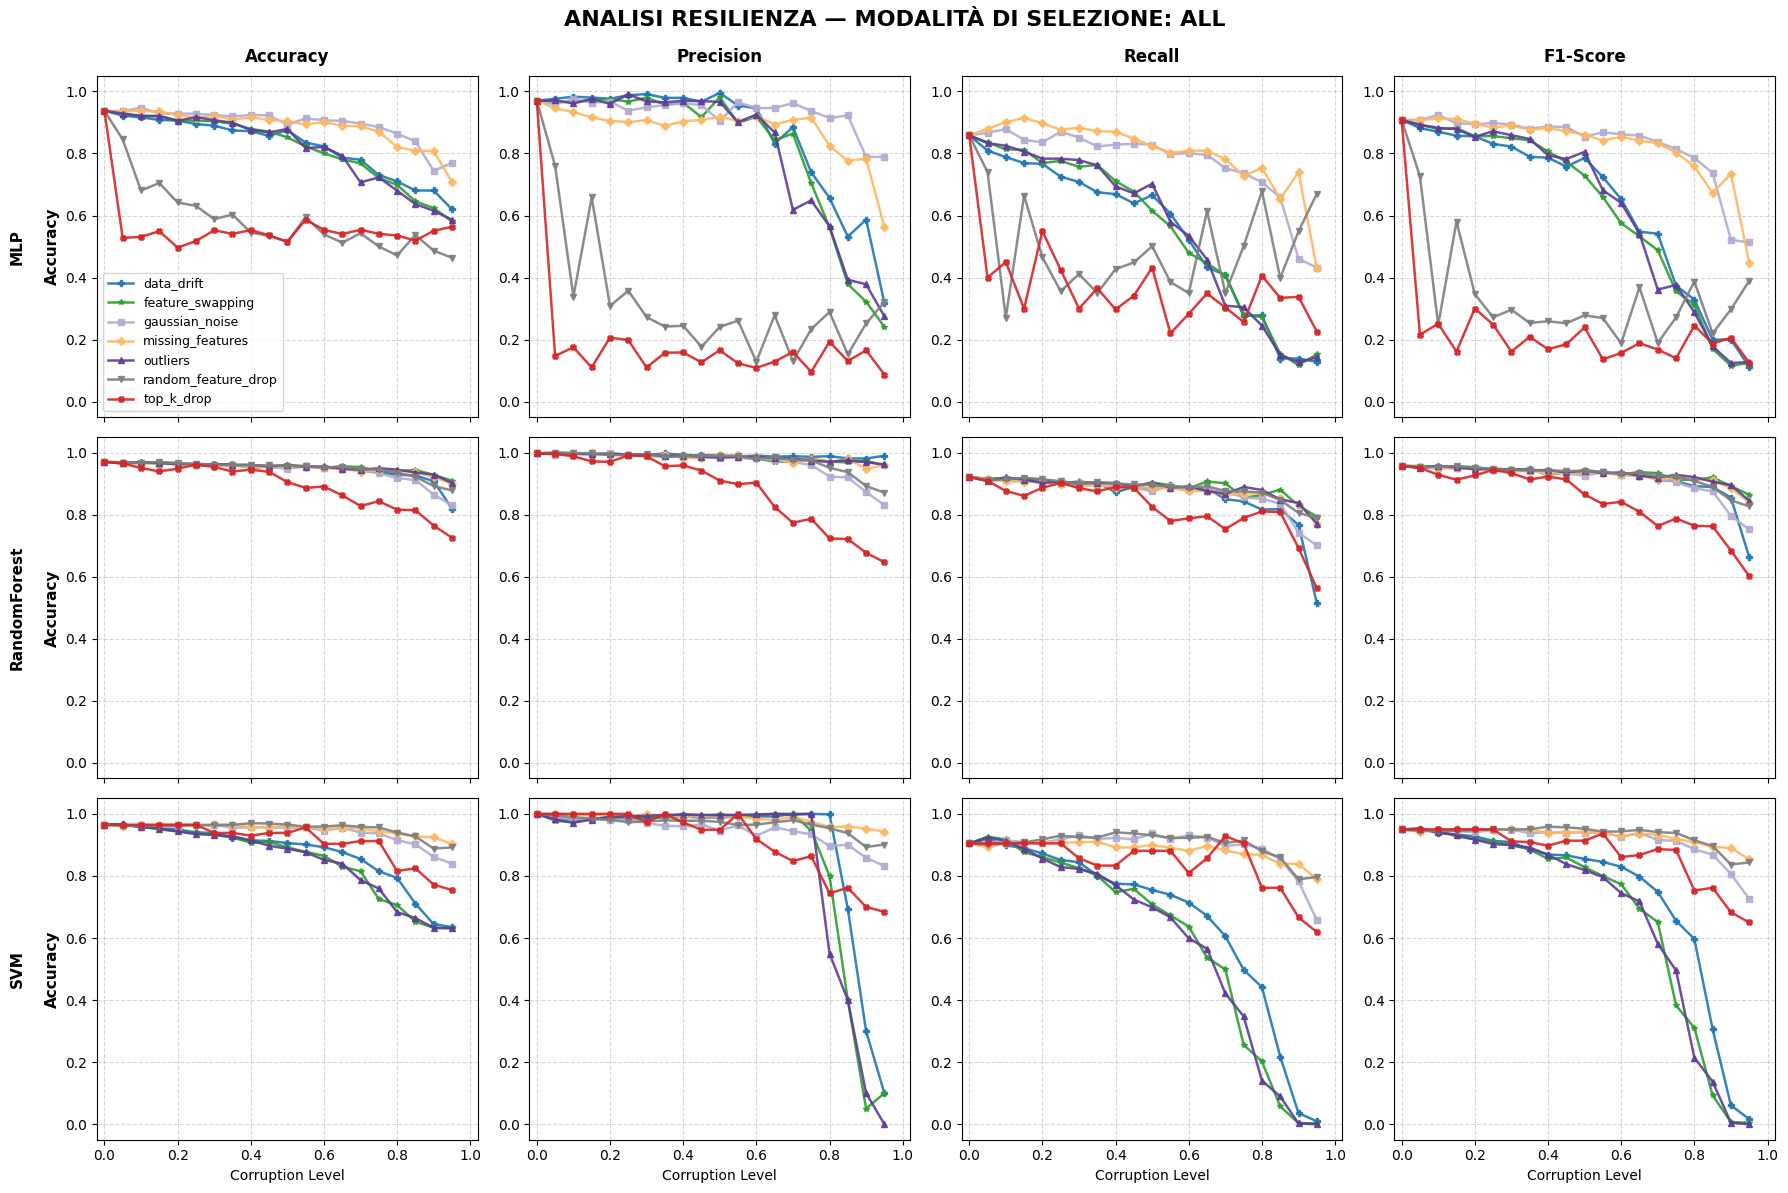

-> Grafico salvato con successo in: risultati\matrice_resilienza_best_3.png


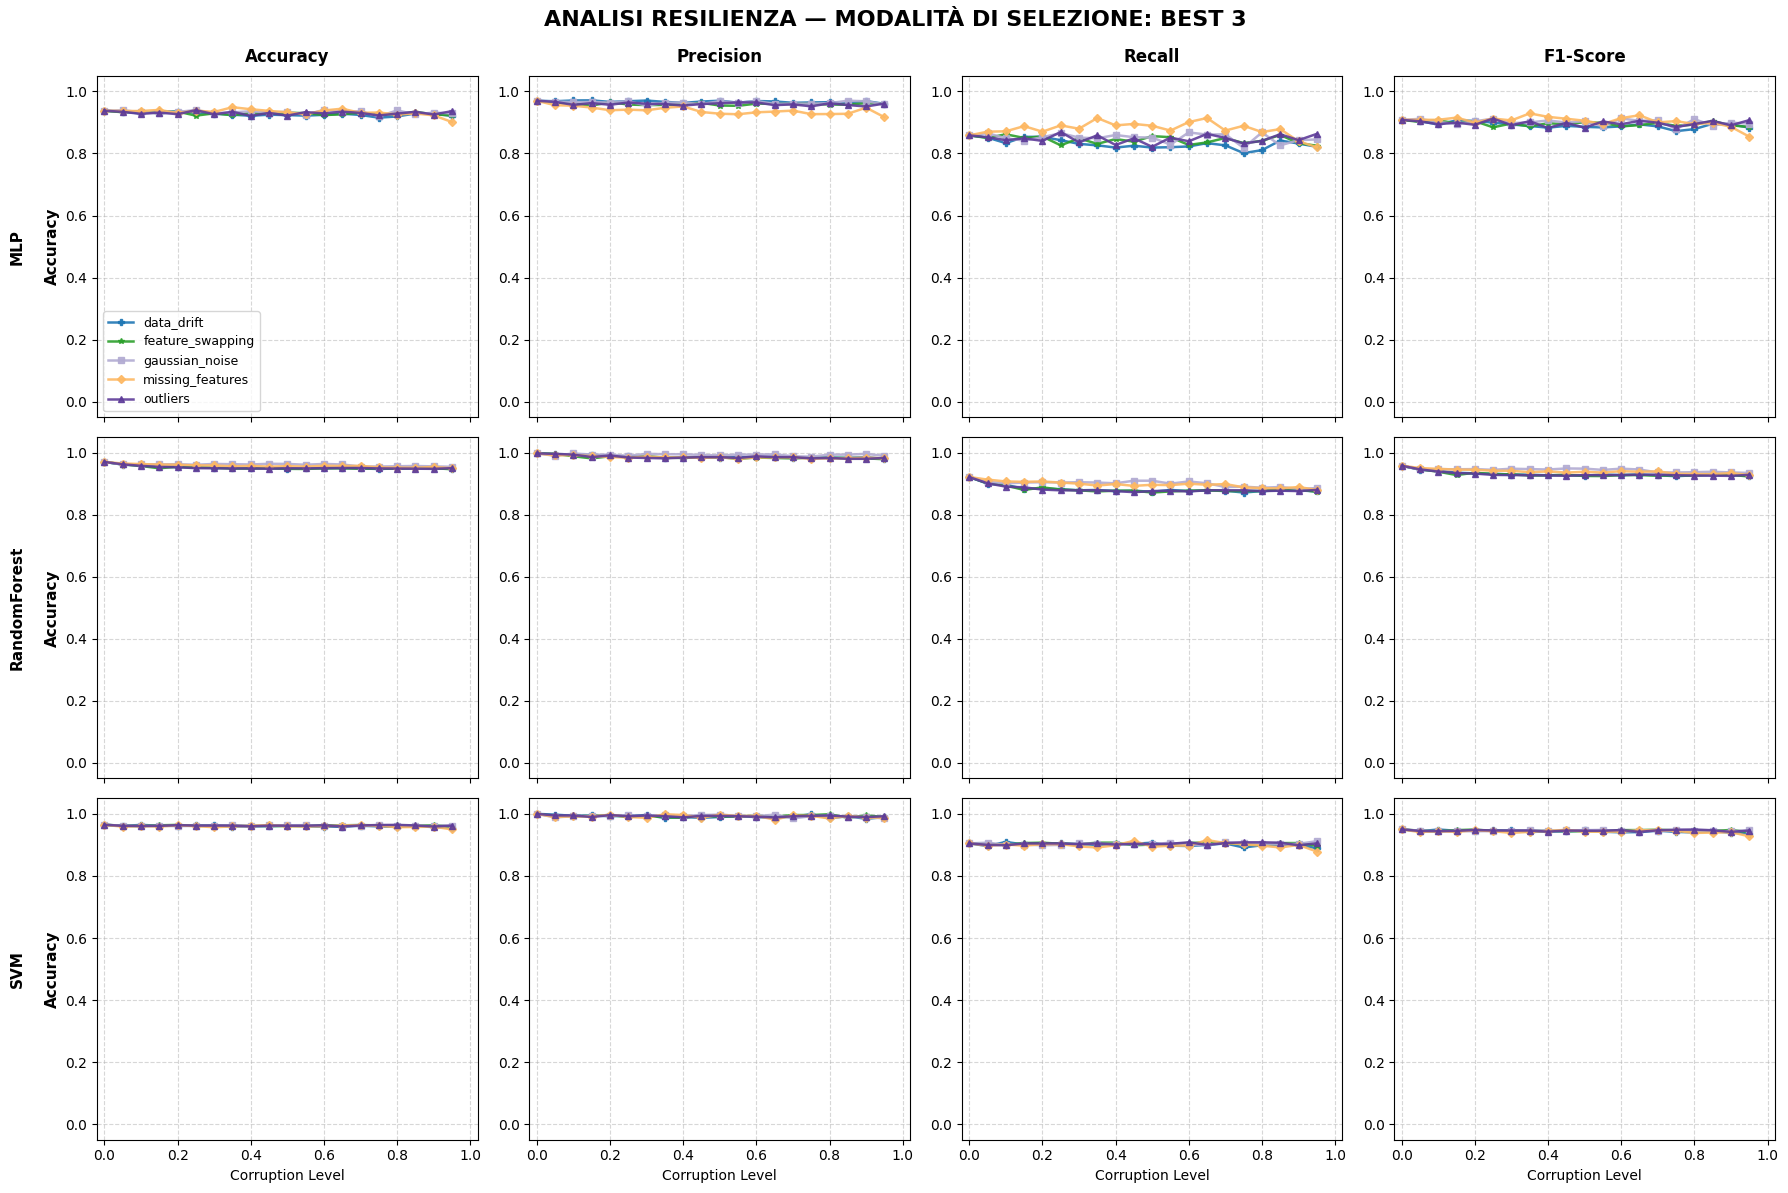

-> Grafico salvato con successo in: risultati\matrice_resilienza_worst_3.png


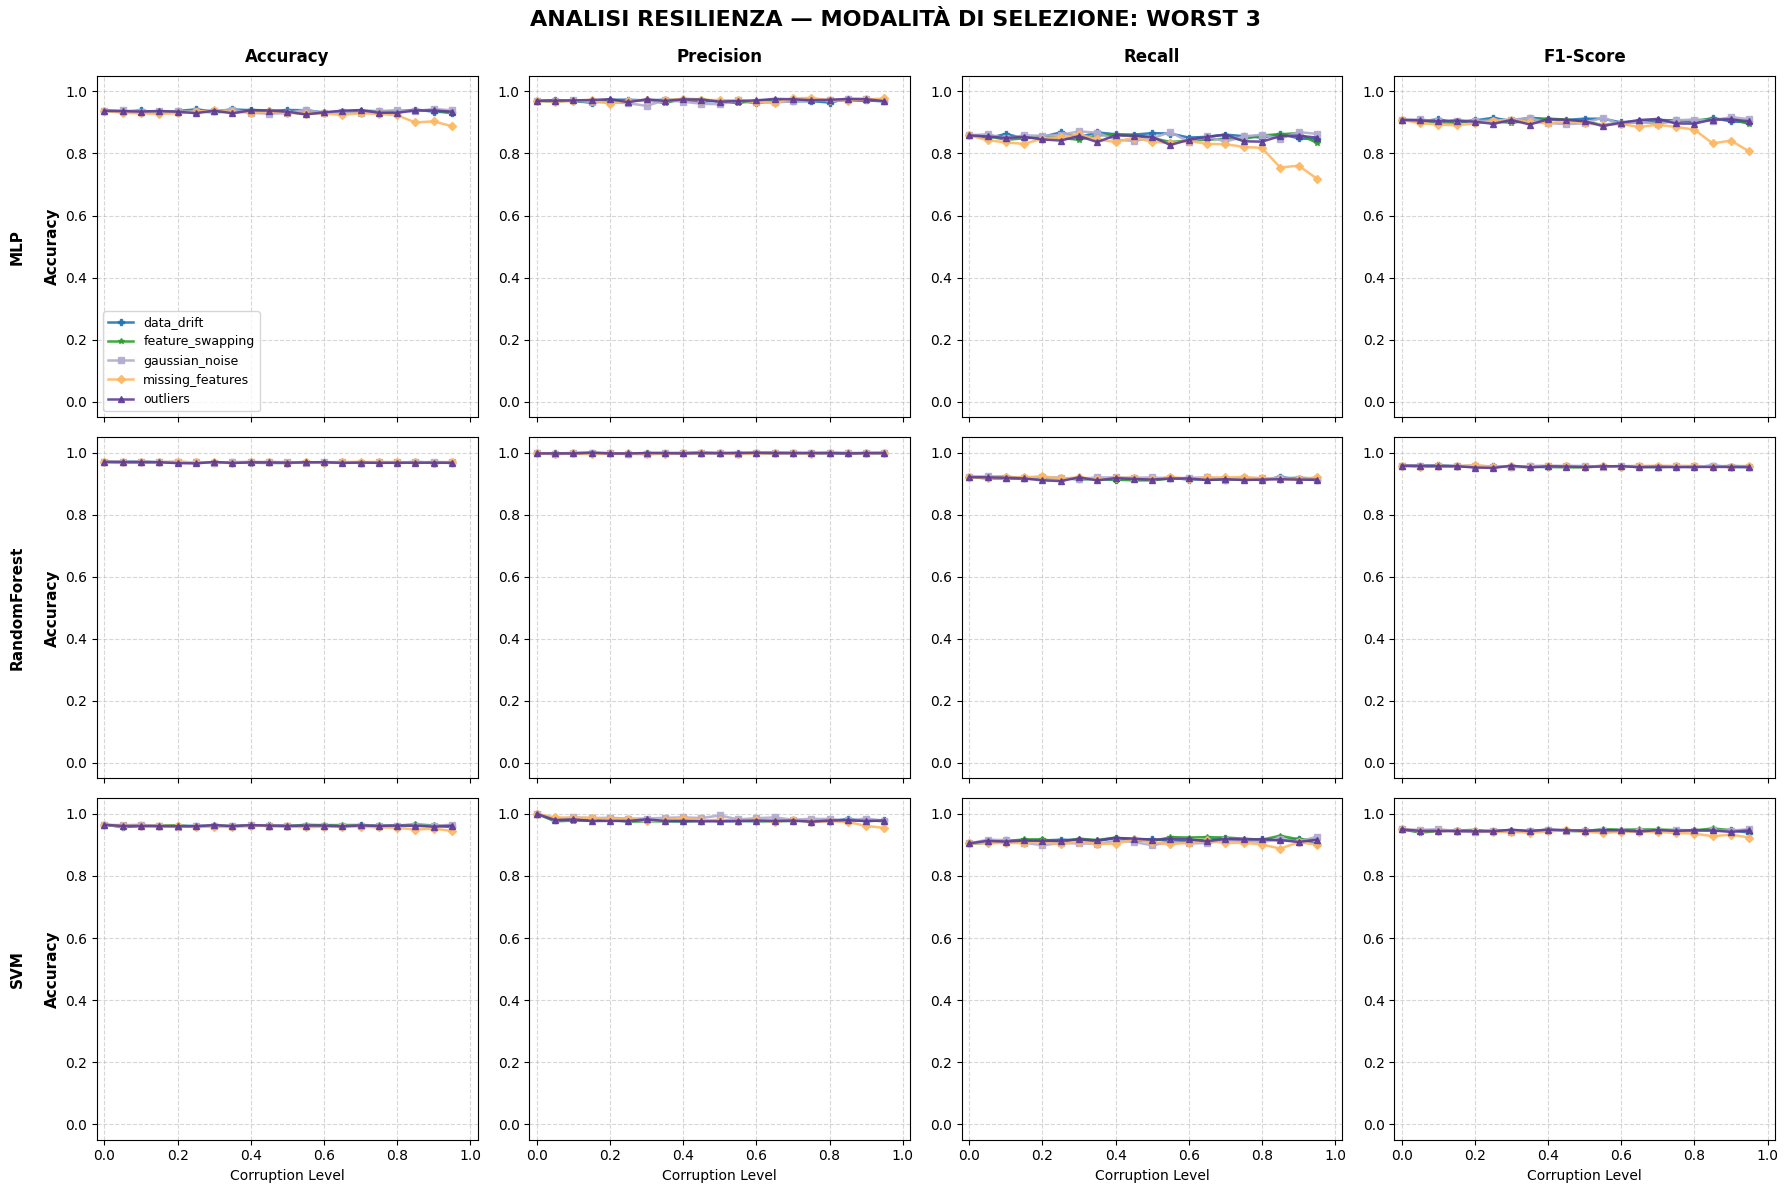

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

METRICS = ["accuracy", "precision", "recall", "f1_score"]
METRIC_LABELS = ["Accuracy", "Precision", "Recall", "F1-Score"]



def plot_selection_mode_matrix(df, selection_mode, output_dir="risultati"):
    """Genera la matrice dei grafici nascondendo i metodi generici se la modalità

    è diversa da 'all'.
    """
    os.makedirs(output_dir, exist_ok=True)

    # 1. Isola la vera baseline pulita globale (livello 0)
    clean_baseline = df[df["corruption_level"] == 0]

    # Filtriamo il DataFrame per la modalità corrente (solo i dati corrotti > 0)
    mode_df = df[
        (df["selection_mode"] == selection_mode) & (df["corruption_level"] > 0)
    ]

    unique_models = df["model"].unique()
    n_models = len(unique_models)
    n_metrics = len(METRICS)

    fig, axes = plt.subplots(
        n_models, n_metrics, figsize=(18, 4 * n_models), sharex=True
    )

    fig.suptitle(
        f"ANALISI RESILIENZA — MODALITÀ DI SELEZIONE: {selection_mode.upper()}",
        fontsize=16,
        fontweight="bold",
        y=0.99,
    )

    for row_idx, model_name in enumerate(unique_models):
        model_corrupted = mode_df[mode_df["model"] == model_name]
        model_clean = clean_baseline[
            clean_baseline["model"] == model_name
        ].drop_duplicates(subset=["model"])

        corruption_types = df[df["model"] == model_name][
            "corruption_type"
        ].unique()

        for col_idx, (metric, label) in enumerate(zip(METRICS, METRIC_LABELS)):
            ax = axes[row_idx, col_idx] if n_models > 1 else axes[col_idx]

            for corr_type in corruption_types:
                # Recuperiamo lo stile e le proprietà del metodo corrente
                style = CORRUPTION_STYLES.get(
                    corr_type, {"color": None, "marker": "x", "is_generic": False}
                )

                # --- FILTRO DINAMICO ---
                # Se il metodo è marcato come generico (is_generic=True) MA non siamo in 'all', lo nascondiamo
                if style.get("is_generic", False) and selection_mode != "all":
                    continue

                if corr_type == "label_flipping":
                    subset_corr = df[
                        (df["model"] == model_name)
                        & (df["corruption_type"] == "label_flipping")
                        & (df["corruption_level"] > 0)
                    ]
                else:
                    subset_corr = model_corrupted[
                        model_corrupted["corruption_type"] == corr_type
                    ]

                attack_baseline = model_clean.copy()
                attack_baseline["corruption_type"] = corr_type
                attack_baseline["selection_mode"] = selection_mode

                combined_subset = pd.concat(
                    [attack_baseline, subset_corr], ignore_index=True
                ).sort_values("corruption_level")

                if not combined_subset.empty:
                    ax.plot(
                        combined_subset["corruption_level"],
                        combined_subset[metric],
                        label=corr_type,
                        color=style["color"],
                        marker=style["marker"],
                        linewidth=1.8,
                        markersize=4,
                        alpha=0.9,
                    )

            if row_idx == 0:
                ax.set_title(label, fontsize=12, fontweight="bold", pad=10)
            if col_idx == 0:
                ax.set_ylabel(
                    f"{model_name}\n\n{label}",
                    fontsize=11,
                    fontweight="semibold",
                )
            else:
                ax.set_ylabel("")

            if row_idx == n_models - 1:
                ax.set_xlabel("Corruption Level", fontsize=10)

            ax.grid(True, linestyle="--", alpha=0.5)
            ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            ax.set_xlim([-0.02, 1.02])
            ax.set_ylim([-0.05, 1.05])

            if row_idx == 0 and col_idx == 0:
                ax.legend(fontsize=9, loc="lower left", frameon=True)

    plt.tight_layout()

    # Salvataggio dell'immagine
    clean_mode_name = selection_mode.replace(" ", "_")
    filename = os.path.join(
        output_dir, f"matrice_resilienza_{clean_mode_name}.png"
    )
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    print(f"-> Grafico salvato con successo in: {filename}")

    plt.show()


# --- Esecuzione del Plotting ---
TARGET_DIR = "risultati"

modes_list = [m for m in results_df["selection_mode"].unique() if pd.notna(m)]
for mode in modes_list:
    plot_selection_mode_matrix(results_df, mode, output_dir=TARGET_DIR)

## 4. Confronto tra modelli

-> Grafico griglia salvato in: risultati\confronto_modelli_feature_all.png


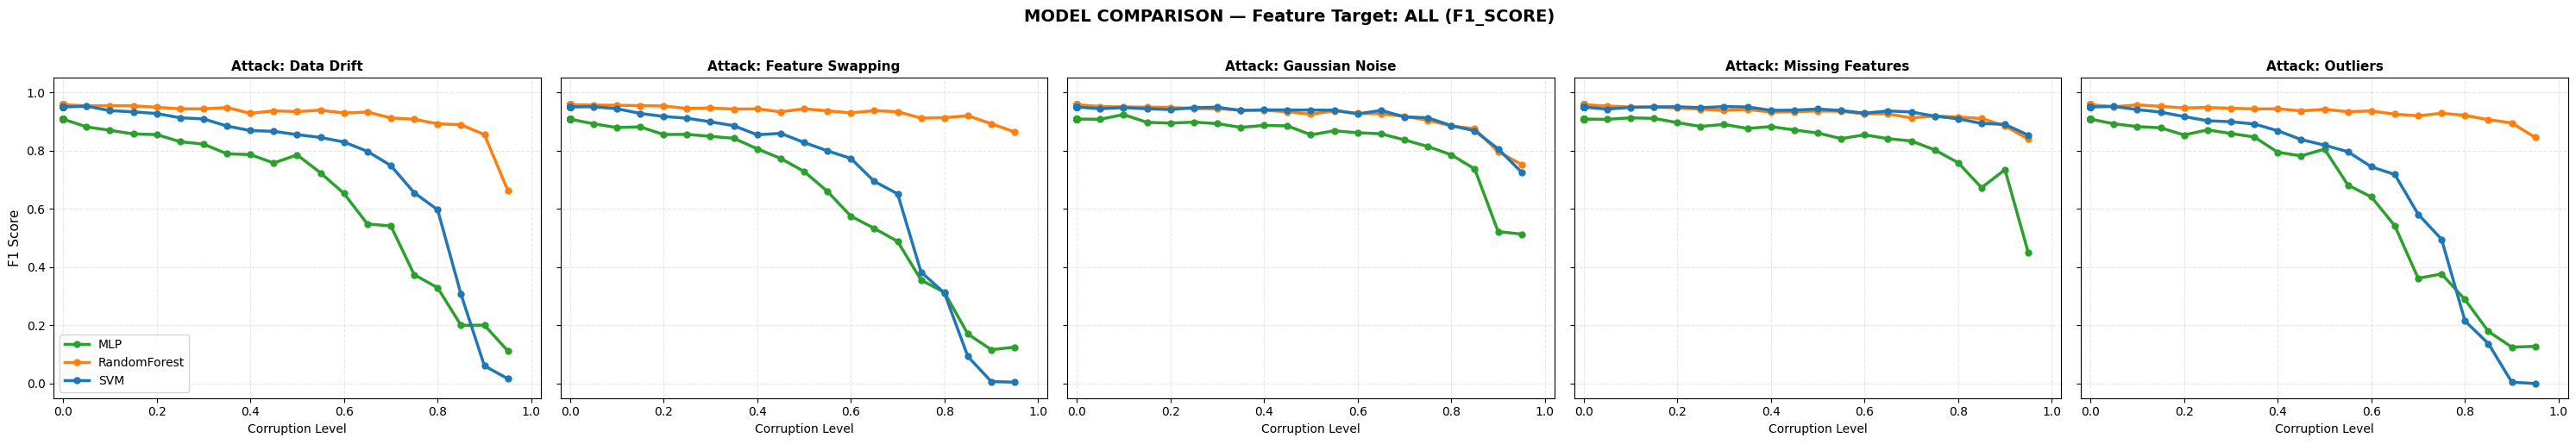

-> Grafico griglia salvato in: risultati\confronto_modelli_feature_best_3.png


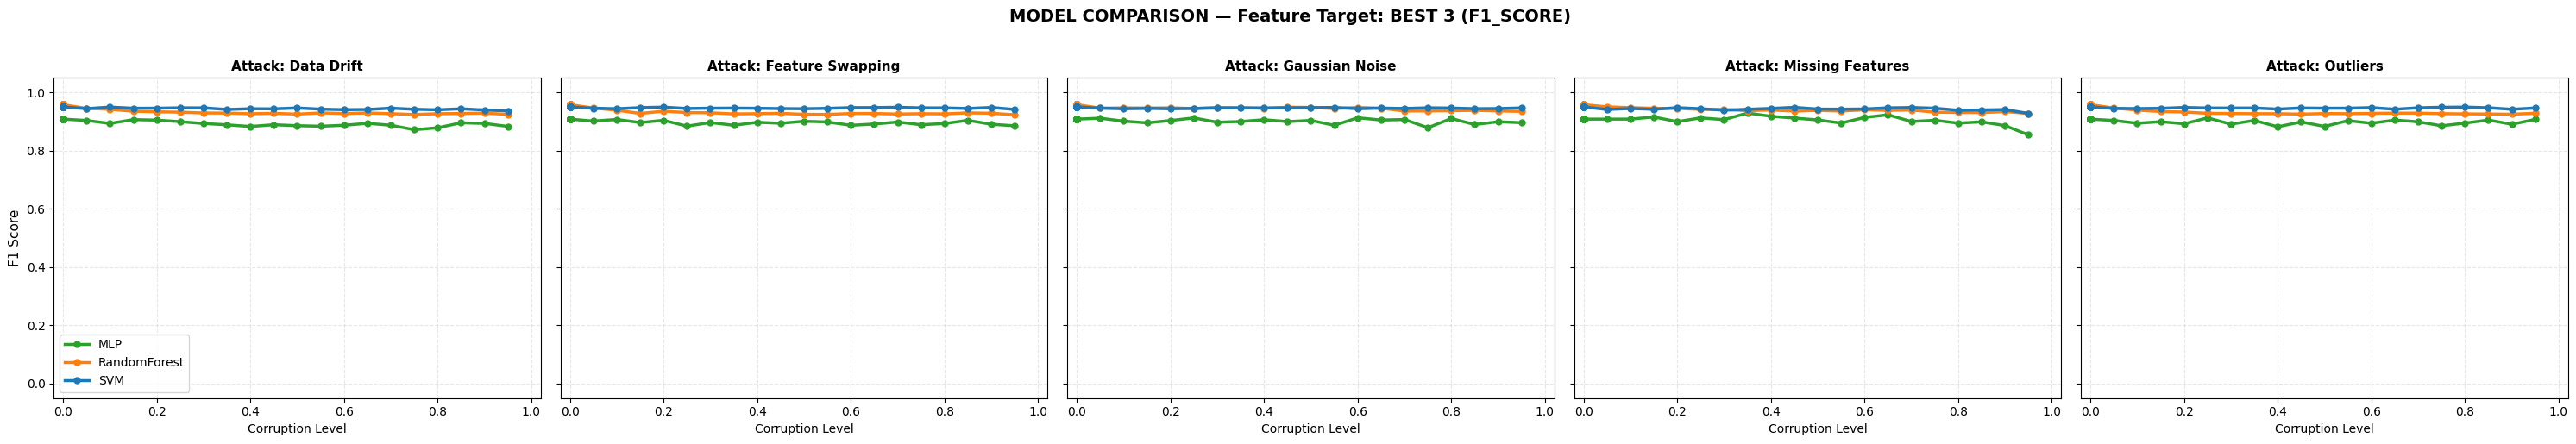

-> Grafico griglia salvato in: risultati\confronto_modelli_feature_worst_3.png


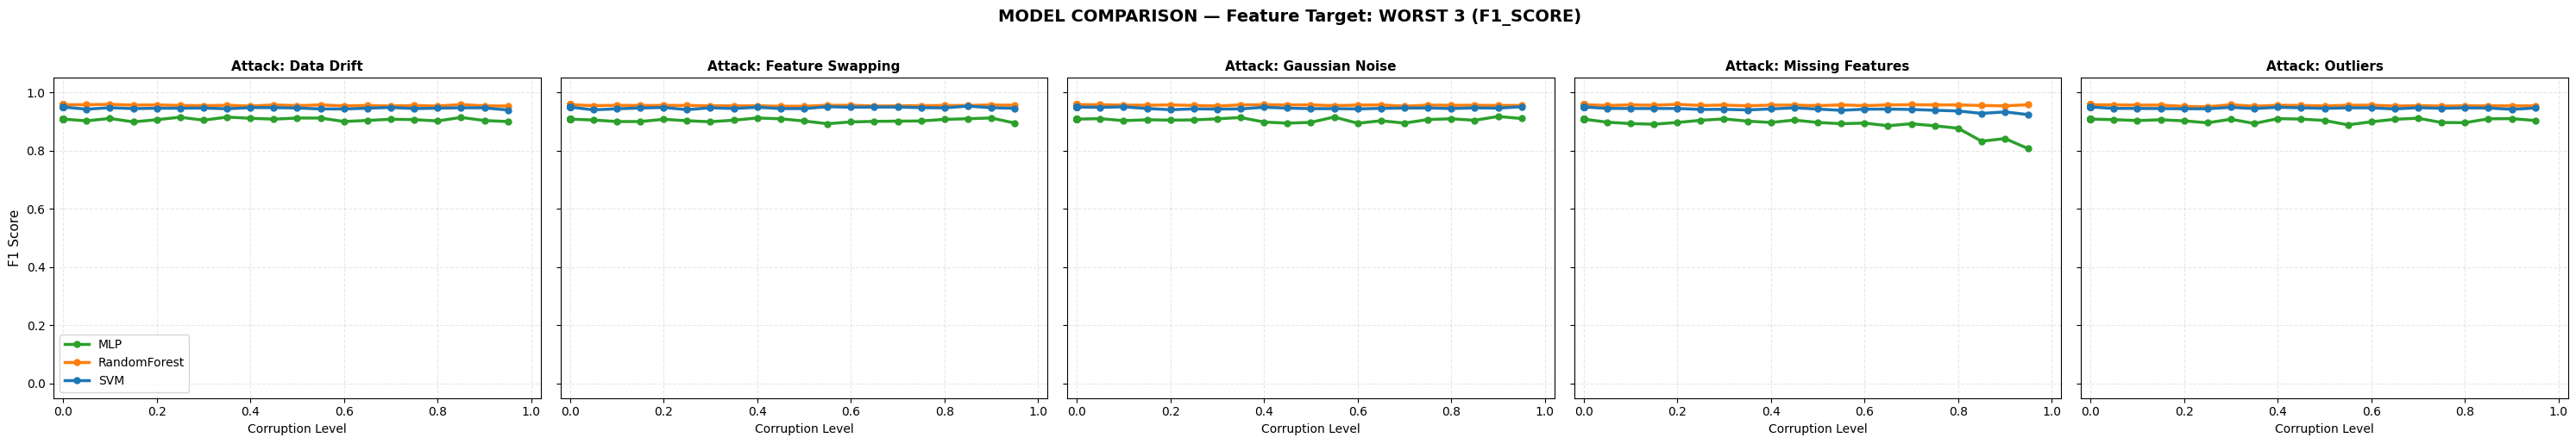

-> Grafico Label Flipping salvato in: risultati\confronto_modelli_label_flipping.png


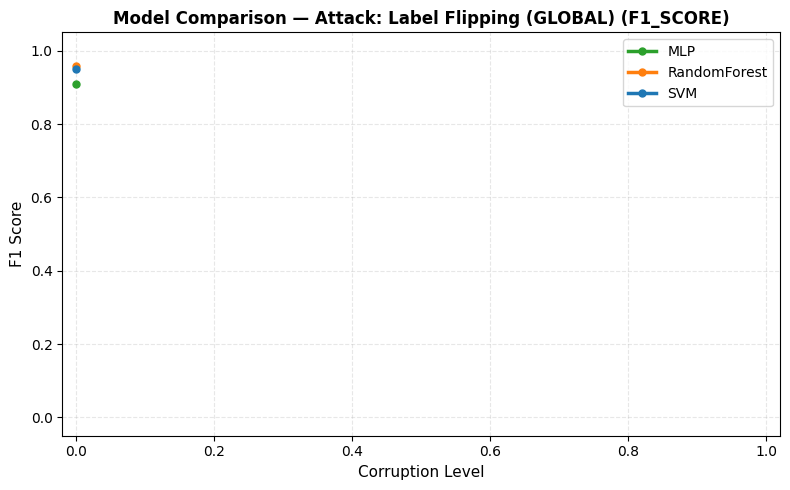

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# Palette colori fissa per i modelli (consistenza visiva globale)
MODELS_COLORS = {
    "SVM": "#1f77b4",  # Blu
    "RandomForest": "#ff7f0e",  # Arancione
    "MLP": "#2ca02c",  # Verde
}


def plot_mode_comparison_grid(
    df, selection_mode, metric="f1_score", output_dir="risultati"
):
    """Genera una singola Figure con 3 grafici affiancati (uno per tipo di attacco alle feature)

    e la salva automaticamente nella cartella specificata.
    """
    # Assicurati che la cartella esista
    os.makedirs(output_dir, exist_ok=True)

    # Identifica tutti gli attacchi escludendo quelli generici non legati alle feature (es. label_flipping)
    feature_attacks = [
        c
        for c in df["corruption_type"].unique()
        if c not in ["label_flipping", "top_k_drop", "random_feature_drop"]
    ]

    # Estraiamo la vera baseline pulita (livello 0) condivisa
    clean_baseline = df[df["corruption_level"] == 0]

    # Calcola il numero di colonne dinamicamente in base agli attacchi effettivi
    n_attacks = len(feature_attacks)
    if n_attacks == 0:
        return

    # Creiamo una Figure dinamica in base al numero di attacchi alle feature
    fig, axes = plt.subplots(
        1, n_attacks, figsize=(6 * n_attacks, 5), sharey=True
    )
    fig.suptitle(
        f"MODEL COMPARISON — Feature Target: {selection_mode.upper()} ({metric.upper()})",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )

    # Filtriamo i dati per la modalità corrente
    mode_df = df[
        (df["selection_mode"] == selection_mode) & (df["corruption_level"] > 0)
    ]

    # Gestione del caso in cui ci sia un solo attacco (axes non sarebbe un array)
    if n_attacks == 1:
        axes = [axes]

    for ax, attack in zip(axes, feature_attacks):
        subset = mode_df[mode_df["corruption_type"] == attack]

        attack_clean_baseline = clean_baseline.copy()
        attack_clean_baseline["corruption_type"] = attack
        attack_clean_baseline["selection_mode"] = selection_mode

        combined_subset = pd.concat(
            [attack_clean_baseline, subset], ignore_index=True
        )

        for model_name in combined_subset["model"].unique():
            model_data = combined_subset[
                combined_subset["model"] == model_name
            ].sort_values("corruption_level")

            if not model_data.empty:
                ax.plot(
                    model_data["corruption_level"],
                    model_data[metric],
                    marker="o",
                    color=MODELS_COLORS.get(model_name, "#7f7f7f"),
                    label=model_name,
                    linewidth=2.5,
                    markersize=5,
                )

        ax.set_xlabel("Corruption Level", fontsize=10)
        ax.set_title(
            f"Attack: {attack.replace('_', ' ').title()}",
            fontsize=11,
            fontweight="semibold",
        )
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.05, 1.05])

        if attack == feature_attacks[0]:
            ax.set_ylabel(metric.replace("_", " ").title(), fontsize=11)
            ax.legend(fontsize=10, loc="best", frameon=True)

    plt.tight_layout()

    # --- SALVATAGGIO GRIGLIA ---
    clean_mode = selection_mode.replace(" ", "_")
    filename = os.path.join(
        output_dir, f"confronto_modelli_feature_{clean_mode}.png"
    )
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    print(f"-> Grafico griglia salvato in: {filename}")

    plt.show()


def plot_label_flipping_only(df, metric="f1_score", output_dir="risultati"):
    """Genera una figure singola per il Label Flipping, includendo la baseline a livello 0

    e salvando il risultato.
    """
    # Assicurati che la cartella esista
    os.makedirs(output_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    clean_baseline = df[df["corruption_level"] == 0].drop_duplicates(
        subset=["model"]
    )
    subset = df[
        (df["corruption_type"] == "label_flipping")
        & (df["corruption_level"] > 0)
    ].drop_duplicates(subset=["model", "corruption_level"])

    clean_baseline_label = clean_baseline.copy()
    clean_baseline_label["corruption_type"] = "label_flipping"

    combined_subset = pd.concat(
        [clean_baseline_label, subset], ignore_index=True
    )

    for model_name in combined_subset["model"].unique():
        model_data = combined_subset[
            combined_subset["model"] == model_name
        ].sort_values("corruption_level")

        if not model_data.empty:
            ax.plot(
                model_data["corruption_level"],
                model_data[metric],
                marker="o",
                color=MODELS_COLORS.get(model_name, "#7f7f7f"),
                label=model_name,
                linewidth=2.5,
                markersize=5,
                
            )

    ax.set_xlabel("Corruption Level", fontsize=11)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=11)
    ax.set_title(
        f"Model Comparison — Attack: Label Flipping (GLOBAL) ({metric.upper()})",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(fontsize=10, loc="best", frameon=True)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.05, 1.05])

    plt.tight_layout()

    # --- SALVATAGGIO LABEL FLIPPING ---
    filename = os.path.join(output_dir, "confronto_modelli_label_flipping.png")
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    print(f"-> Grafico Label Flipping salvato in: {filename}")

    plt.show()


# ----------------------------------------------------
# 2. ESECUZIONE DEL PLOTTING IN LINEA
# ----------------------------------------------------
TARGET_DIR = "risultati"

# 1. Matrice di confronto per attacchi alle feature
modes_list = [m for m in results_df["selection_mode"].unique() if pd.notna(m)]
for mode in modes_list:
    plot_mode_comparison_grid(
        results_df, selection_mode=mode, metric="f1_score", output_dir=TARGET_DIR
    )

# 2. Grafico singolo finale per l'attacco ai label
plot_label_flipping_only(results_df, metric="f1_score", output_dir=TARGET_DIR)